# 4.1b — eQTL Concordance: GTEx v10 Muscle Skeletal

Tests whether AlphaGenome-predicted $V_G$ agrees with empirical eQTL-derived $V_G$
computed from GTEx v10 significant pairs (Muscle Skeletal).

**Narrative:**
1. Compute $V_G^{\mathrm{eQTL}}$ per gene from v10 signif_pairs: $\sum_i \beta_i^2 \cdot 2f_i(1-f_i)$
2. Join with predicted $V_G$ from gene parquets
3. Show variant-level scatter is noisy; gene-level aggregation is significant
4. Enhanced scatter with OLS regression lines (main figure for thesis)


In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats


import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140


def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "config.py").exists():
            return candidate
    raise FileNotFoundError("config.py not found in cwd or parents")


PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import GENE_PATHS, VARIANT_PATHS
from utils.plot_utils import save_plot, autosave
from utils.thesis_model_validation import (
    AG_BORZOI_ROOT,
    THESIS_FIGURE_DIR,
    plot_ag_borzoi_correlations,
    plot_eqtl_concordance,
    plot_representative_gene_scatter,
    plot_variant_effect_distributions,
    summarize_ag_borzoi_correlations,
    summarize_eqtl_concordance,
    summarize_variant_effects,
)

NOTEBOOK_NAME = "4_1_model_validation_and_baseline_characterization"
THESIS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Thesis figures: {THESIS_FIGURE_DIR}")
print("\nGene parquets:")
for name in ("clingen", "background"):
    print(f"  {name}: {GENE_PATHS[name].name}")
print("\nVariant parquets:")
for name in ("clingen", "background"):
    print(f"  {name}: {VARIANT_PATHS[name].name}")
print(f"\nAG/Borzoi source present: {AG_BORZOI_ROOT.exists()}")

# ── project root ──────────────────────────────────────────────────────────────
def _resolve_root() -> Path:
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / 'config.py').exists():
            return p
    raise FileNotFoundError('config.py not found')

PROJECT_ROOT = _resolve_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import GENE_PATHS, SOURCE_PALETTE, DISPLAY_NAMES
from utils.plot_utils import save_plot

# ── thesis style ──────────────────────────────────────────────────────────────
_thesis_dir = str(PROJECT_ROOT / '10_THESIS')
if _thesis_dir not in sys.path:
    sys.path.insert(0, _thesis_dir)
import thesis_style
from thesis_style import (
    apply_thesis_style, sig_stars, sig_label, save_figure,
    add_panel_letter, add_panel_letters, despine_all,
    outside_legend, annotate_pval, enable_log_minor_grid,
)

NOTEBOOK_NAME   = '4_1b_eqtl_v10_concordance'
FIGURE_DIR      = PROJECT_ROOT / '10_THESIS' / 'FIGURES_FOR_THESIS'
FIGURE_DIR.mkdir(exist_ok=True)

# ── data paths ────────────────────────────────────────────────────────────────
EQTL_V10_DIR = Path(
    '/Users/markus/master-thesis-lappalainen/seq2expr-variance/data/intermediate'
    '/eQTL_v10/GTEx_Analysis_v10_eQTL_updated'
)
SIGNIF_PAIRS_PATH = EQTL_V10_DIR / 'Muscle_Skeletal.v10.eQTLs.signif_pairs.parquet'
EGENES_PATH       = EQTL_V10_DIR / 'Muscle_Skeletal.v10.eGenes.txt.gz'

COLOR_POOLED = SOURCE_PALETTE['pooled_real']
LABEL_POOLED = DISPLAY_NAMES['pooled_real'].replace('\n', ' ')

print(f'Project root : {PROJECT_ROOT}')
print(f'Signif pairs : {SIGNIF_PAIRS_PATH.exists()}')
print(f'eGenes       : {EGENES_PATH.exists()}')


Project root: /Users/markus/master-thesis-lappalainen/in-silico-vg-analysis
Thesis figures: /Users/markus/master-thesis-lappalainen/in-silico-vg-analysis/10_THESIS/FIGURES_FOR_THESIS

Gene parquets:
  clingen: ClinGen_HI_Gnomad_genes_22042026_polya.parquet
  background: Background_Gnomad_genes_30032026_polya.parquet

Variant parquets:
  clingen: ClinGen_HI_Gnomad_variants_dedup_22042026_polya.parquet
  background: Background_Gnomad_variants_dedup_perm_30032026_polya.parquet

AG/Borzoi source present: True
Project root : /Users/markus/master-thesis-lappalainen/in-silico-vg-analysis
Signif pairs : True
eGenes       : True


## 1. Compute gene-level $V_G^{\mathrm{eQTL}}$ from GTEx v10

For each gene: $V_G^{\mathrm{eQTL}} = \sum_i \beta_i^2 \cdot 2f_i(1-f_i)$
over all significant eQTL pairs.  
This is a **lower bound** — only variants that reach significance in the
GTEx muscle cohort are included.

In [6]:
signif = pl.read_parquet(SIGNIF_PAIRS_PATH)
print(f'v10 signif_pairs: {signif.height:,} rows, {signif["gene_id"].n_unique():,} genes')
print('columns:', signif.columns)


v10 signif_pairs: 3,147,347 rows, 14,957 genes
columns: ['gene_id', 'variant_id', 'tss_distance', 'af', 'ma_samples', 'ma_count', 'pval_nominal', 'slope', 'slope_se', 'pval_nominal_threshold', 'min_pval_nominal', 'pval_beta']


In [7]:
eqtl_with_vg = (
    signif
    .filter((pl.col('af') > 0) & (pl.col('af') < 1) & pl.col('slope').is_not_null())
    .with_columns(
        [
            (pl.col('slope').pow(2) * 2 * pl.col('af') * (1 - pl.col('af'))).alias('vg_contrib'),
            pl.col('gene_id').str.split('.').list.first().alias('gene_id_base'),
        ]
    )
)

vg_eqtl_v10 = (
    eqtl_with_vg
    .group_by('gene_id_base')
    .agg(pl.col('vg_contrib').sum().alias('vg_eqtl_v10'))
)

vg_eqtl_v10_20kb = (
    eqtl_with_vg
    .filter(pl.col('tss_distance').abs() <= 20_000)
    .group_by('gene_id_base')
    .agg(pl.col('vg_contrib').sum().alias('vg_eqtl_v10_20kb'))
)

vg_eqtl_v10 = vg_eqtl_v10.join(vg_eqtl_v10_20kb, on='gene_id_base', how='left')

print(f'Genes with v10 Vg_eQTL: {vg_eqtl_v10.height:,}')
print(f'Genes with v10 Vg_eQTL within 20 kb: {vg_eqtl_v10["vg_eqtl_v10_20kb"].drop_nulls().len():,}')
print(f'Median Vg_eQTL_v10: {vg_eqtl_v10["vg_eqtl_v10"].median():.4e}')
print(f'Median Vg_eQTL_v10_20kb: {vg_eqtl_v10["vg_eqtl_v10_20kb"].median():.4e}')


Genes with v10 Vg_eQTL: 14,957
Genes with v10 Vg_eQTL within 20 kb: 11,850
Median Vg_eQTL_v10: 7.2667e-01
Median Vg_eQTL_v10_20kb: 2.6670e-01


## 2. Join with predicted $V_G$ from gene parquets

In [8]:
def load_and_join(dataset_key: str) -> pd.DataFrame:
    gene_df = pl.read_parquet(GENE_PATHS[dataset_key])

    gene_df = gene_df.with_columns(
        pl.col('gene_id').str.split('.').list.first().alias('gene_id_base')
    )

    joined = gene_df.join(
        vg_eqtl_v10.select(['gene_id_base', 'vg_eqtl_v10', 'vg_eqtl_v10_20kb']),
        on='gene_id_base',
        how='left',
    )
    pdf = joined.select(
        ['gene_id', 'vg_predicted', 'vg_eqtl', 'vg_eqtl_v10', 'vg_eqtl_v10_20kb']
    ).to_pandas()
    pdf['dataset'] = dataset_key
    return pdf

real_datasets = ('clingen', 'background')
df_by_dataset = {dataset_key: load_and_join(dataset_key) for dataset_key in real_datasets}
df_all = pd.concat(df_by_dataset.values(), ignore_index=True)

n_v10 = df_all['vg_eqtl_v10'].notna().sum()
n_v10_20kb = df_all['vg_eqtl_v10_20kb'].notna().sum()
n_old = df_all['vg_eqtl'].notna().sum()
print(
    f'{LABEL_POOLED}: {len(df_all)} genes | v10 coverage: {n_v10} | '
    f'v10 20kb coverage: {n_v10_20kb} | legacy vg_eqtl: {n_old}'
)


All variants: 665 genes | v10 coverage: 434 | v10 20kb coverage: 333 | legacy vg_eqtl: 628


## 3. Concordance summary table

In [9]:
def concordance_row(df: pd.DataFrame, label: str, y_col: str) -> dict:
    sub = df[['vg_predicted', y_col]].dropna()
    sub = sub[(sub['vg_predicted'] > 0) & (sub[y_col] > 0)]
    if len(sub) < 5:
        return {
            'dataset': label,
            'comparison': y_col,
            'n': len(sub),
            'pearson_r': np.nan,
            'spearman_rho': np.nan,
            'p': np.nan,
        }
    lx = np.log10(sub['vg_predicted'].values)
    ly = np.log10(sub[y_col].values)
    r, p_r = stats.pearsonr(lx, ly)
    rho, p_s = stats.spearmanr(lx, ly)
    return {
        'dataset': label,
        'comparison': f'vg_predicted vs {y_col}',
        'n': len(sub),
        'pearson_r': round(r, 3),
        'spearman_rho': round(rho, 3),
        'p_pearson': f'{p_r:.2e}',
        'p_spearman': f'{p_s:.2e}',
    }

rows = [
    concordance_row(df_all, LABEL_POOLED, 'vg_eqtl_v10'),
    concordance_row(df_all, LABEL_POOLED, 'vg_eqtl_v10_20kb'),
    concordance_row(df_all, LABEL_POOLED, 'vg_eqtl'),
]

summary = pd.DataFrame(rows)
display(summary)


,dataset,comparison,n,pearson_r,spearman_rho,p_pearson,p_spearman
0,All variants,vg_predicted vs vg_eqtl_v10,434,0.218,0.205,4.65e-06,1.74e-05
1,All variants,vg_predicted vs vg_eqtl_v10_20kb,333,0.248,0.211,4.69e-06,1.03e-04
2,All variants,vg_predicted vs vg_eqtl,628,0.432,0.430,5.33e-30,1.07e-29


## 4. Enhanced scatter: predicted $V_G$ vs $V_G^{\mathrm{eQTL}}$ (v10)

Enhancements over existing `plot_eqtl_concordance()`:
- Pooled real variants without ClinGen/background distinction
- OLS regression line on log-log scale
- 95 % confidence band around regression
- Identity line (dashed grey) as reference
- Clean annotation with n, r, ρ, p


[save_plot] Saved: 4_1b_eqtl_v10_concordance_4.1b_gene_level_vg_eqtl_v10_20kb_04052026_1641.pdf
[save_plot] Saved: 4_1b_eqtl_v10_concordance_4.1b_gene_level_vg_eqtl_v10_20kb_04052026_1641.svg


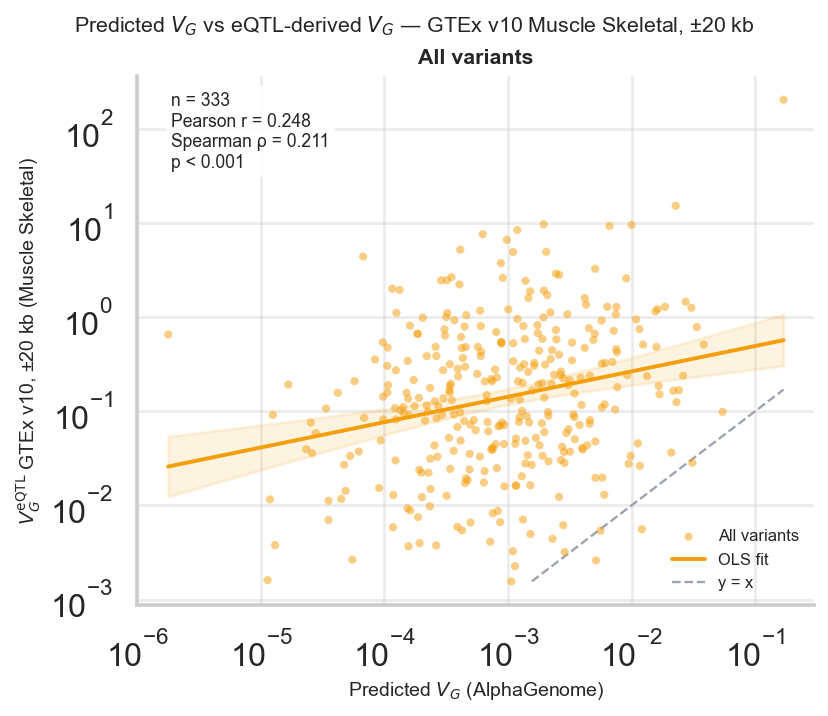

In [10]:
def _ols_log(x: np.ndarray, y: np.ndarray):
    """OLS on log10-transformed data. Returns slope, intercept."""
    lx, ly = np.log10(x), np.log10(y)
    return stats.linregress(lx, ly)


def _prediction_band(x_vals, lx, ly, slope, intercept, alpha=0.05):
    """95% confidence band for OLS regression on log-log scale."""
    n = len(lx)
    y_hat = slope * lx + intercept
    se2 = np.sum((ly - y_hat) ** 2) / (n - 2)
    x_bar = np.mean(lx)
    ss_x = np.sum((lx - x_bar) ** 2)
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 2)
    se_fit = np.sqrt(se2 * (1 / n + (x_vals - x_bar) ** 2 / ss_x))
    y_fit = slope * x_vals + intercept
    return y_fit, se_fit * t_crit


def plot_vg_eqtl_v10_enhanced(
    y_col: str = 'vg_eqtl_v10_20kb',
    y_label: str = r'$V_G^{\mathrm{eQTL}}$ GTEx v10, ±20 kb (Muscle Skeletal)',
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(5.8, 5), constrained_layout=True)

    sub = df_all[['vg_predicted', y_col]].dropna()
    sub = sub[(sub['vg_predicted'] > 0) & (sub[y_col] > 0)]

    x = sub['vg_predicted'].values
    y = sub[y_col].values
    lx = np.log10(x)
    ly = np.log10(y)

    r, p_r = stats.pearsonr(lx, ly)
    rho, _ = stats.spearmanr(lx, ly)

    ax.scatter(
        x,
        y,
        s=18,
        alpha=0.50,
        color=COLOR_POOLED,
        edgecolors='none',
        zorder=2,
        rasterized=True,
        label=LABEL_POOLED,
    )

    res = _ols_log(x, y)
    x_grid = np.linspace(lx.min(), lx.max(), 200)
    y_fit, half_band = _prediction_band(x_grid, lx, ly, res.slope, res.intercept)
    ax.plot(10**x_grid, 10**y_fit, color=COLOR_POOLED, lw=2.0, zorder=4, label='OLS fit')
    ax.fill_between(
        10**x_grid,
        10 ** (y_fit - half_band),
        10 ** (y_fit + half_band),
        color=COLOR_POOLED,
        alpha=0.12,
        zorder=3,
    )

    xy_min = max(x.min(), y.min())
    xy_max = min(x.max(), y.max())
    if xy_min < xy_max:
        ax.plot(
            [xy_min, xy_max],
            [xy_min, xy_max],
            color='#9CA3AF',
            lw=1.2,
            ls='--',
            zorder=1,
            label='y = x',
        )

    p_str = 'p < 0.001' if p_r < 0.001 else f'p = {p_r:.3f}'
    ax.text(
        0.05,
        0.97,
        f'n = {len(sub)}\n'
        f'Pearson r = {r:.3f}\n'
        f'Spearman ρ = {rho:.3f}\n'
        f'{p_str}',
        transform=ax.transAxes,
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='none'),
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'Predicted $V_G$ (AlphaGenome)', fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(LABEL_POOLED, fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=8.5)
    sns.despine(ax=ax)

    fig.suptitle(
        r'Predicted $V_G$ vs eQTL-derived $V_G$ — GTEx v10 Muscle Skeletal, ±20 kb',
        fontsize=11,
    )
    return fig


fig = plot_vg_eqtl_v10_enhanced()
save_plot(
    fig=fig,
    title='4.1b_gene_level_vg_eqtl_v10_20kb',
    notebook=NOTEBOOK_NAME,
    outdir=FIGURE_DIR,
)
plt.show()


## 5. Comparison: legacy `vg_eqtl` vs v10

Quick check that v10 and the existing parquet `vg_eqtl` tell the same story.

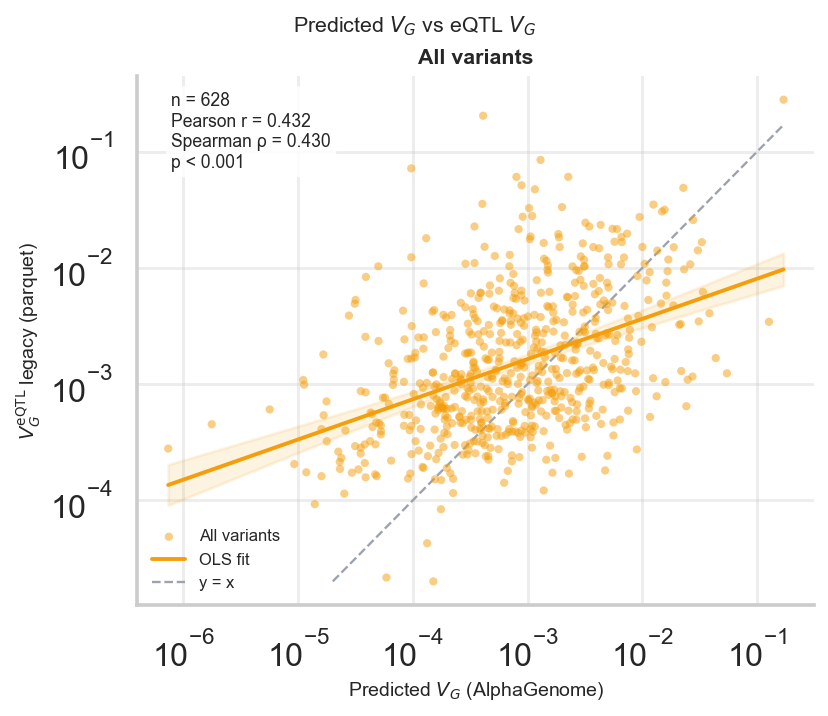

[save_plot] Saved: 4_1b_eqtl_v10_concordance_4.1b_gene_level_vg_eqtl_legacy_pooled_04052026_1641.pdf
[save_plot] Saved: 4_1b_eqtl_v10_concordance_4.1b_gene_level_vg_eqtl_legacy_pooled_04052026_1641.svg


['/Users/markus/master-thesis-lappalainen/in-silico-vg-analysis/10_THESIS/FIGURES_FOR_THESIS/4_1b_eqtl_v10_concordance_4.1b_gene_level_vg_eqtl_legacy_pooled_04052026_1641.pdf',
 '/Users/markus/master-thesis-lappalainen/in-silico-vg-analysis/10_THESIS/FIGURES_FOR_THESIS/4_1b_eqtl_v10_concordance_4.1b_gene_level_vg_eqtl_legacy_pooled_04052026_1641.svg']

In [11]:
fig_legacy = plot_vg_eqtl_v10_enhanced(
    y_col='vg_eqtl',
    y_label=r'$V_G^{\mathrm{eQTL}}$ legacy (parquet)',
)
fig_legacy.suptitle(
    r'Predicted $V_G$ vs eQTL $V_G$',
    fontsize=11,
)
plt.show()
save_plot(
    fig=fig_legacy,
    title='4.1b_gene_level_vg_eqtl_legacy_pooled',
    notebook=NOTEBOOK_NAME,
    outdir=FIGURE_DIR,
)


## 6. Coverage: how many study genes have a v10 eQTL?

This directly motivates why we need predicted $V_G$.

In [12]:
has_v10 = df_all['vg_eqtl_v10'].notna() & (df_all['vg_eqtl_v10'] > 0)
pct = has_v10.mean() * 100
print(f'{LABEL_POOLED}: {has_v10.sum()}/{len(df_all)} genes have v10 eQTL ({pct:.1f}%)')
print(f'  {100 - pct:.1f}% have no v10 muscle eQTL; predicted Vg is the only source')


All variants: 434/665 genes have v10 eQTL (65.3%)
  34.7% have no v10 muscle eQTL; predicted Vg is the only source


## 7. Fine-mapped Muscle Skeletal eQTL coverage by gene set

Keep this figure split by ClinGen HI and background genes. It summarizes GTEx v11 SuSiE coverage rather than pooled variant-level concordance.

ClinGen HI: 67/316 = 21.2%
Background: 157/349 = 45.0%
chi2 p = 1.57e-10
[save_plot] Saved: 4_1b_eqtl_v10_concordance_figure_5_susie_hi_vs_background_coverage_04052026_1641.pdf
[save_plot] Saved: 4_1b_eqtl_v10_concordance_figure_5_susie_hi_vs_background_coverage_04052026_1641.svg


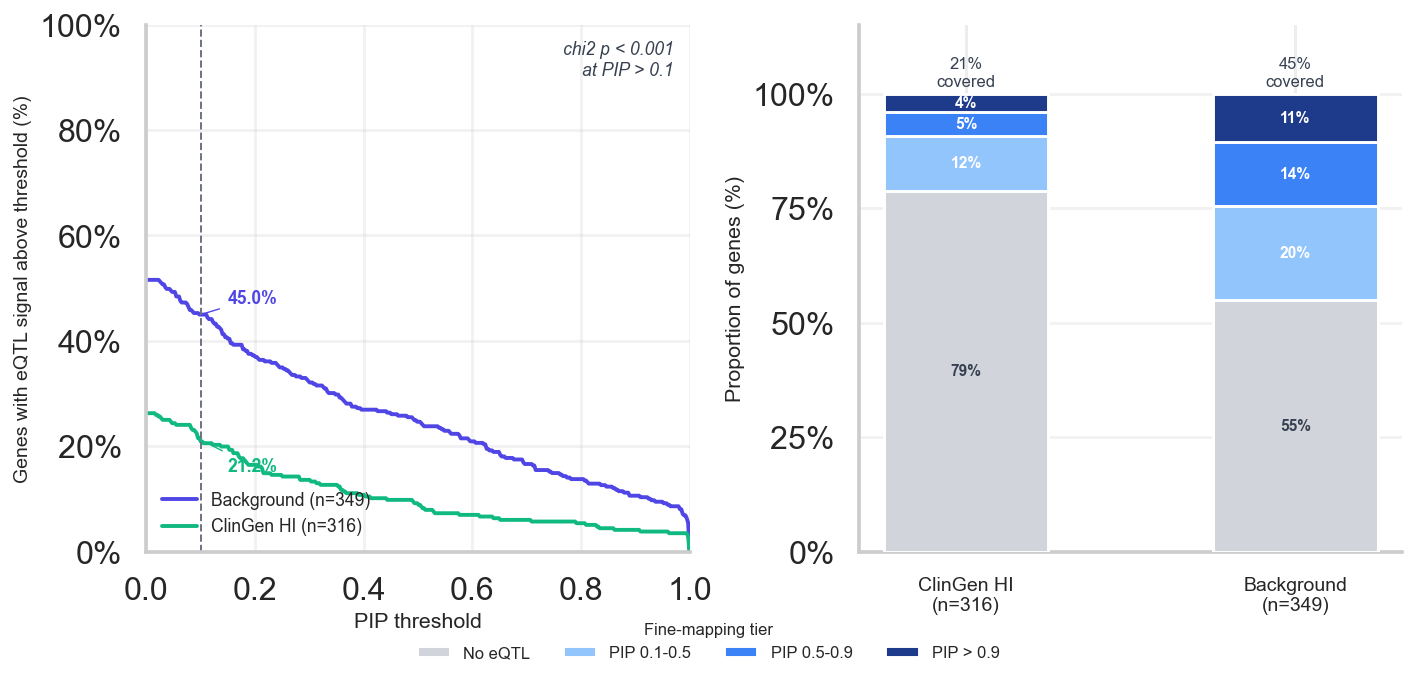

In [13]:
from scipy.stats import chi2_contingency
import matplotlib.ticker as mticker

SUSIE_PATH = PROJECT_ROOT / '09_3103_biweekly' / 'Muscle_Skeletal.v11.eQTLs.SuSiE_summary.parquet'
SUSIE_PIP_THRESHOLD = 0.1

susie = (
    pl.read_parquet(SUSIE_PATH)
    .with_columns(pl.col('phenotype_id').str.replace(r'\..*$', '').alias('gene_id'))
)

hi_genes = pl.read_parquet(GENE_PATHS['clingen']).select('gene_id')
bg_genes = pl.read_parquet(GENE_PATHS['background']).select('gene_id')
hi_total = hi_genes.height
bg_total = bg_genes.height

max_pip_per_gene = susie.group_by('gene_id').agg(pl.col('pip').max().alias('max_pip'))
hi_max_pip = (
    hi_genes
    .join(max_pip_per_gene, on='gene_id', how='left')
    .with_columns(pl.col('max_pip').fill_null(0.0))
    ['max_pip'].to_numpy()
)
bg_max_pip = (
    bg_genes
    .join(max_pip_per_gene, on='gene_id', how='left')
    .with_columns(pl.col('max_pip').fill_null(0.0))
    ['max_pip'].to_numpy()
)

hi_pass = int((hi_max_pip > SUSIE_PIP_THRESHOLD).sum())
bg_pass = int((bg_max_pip > SUSIE_PIP_THRESHOLD).sum())
pct_hi = 100 * hi_pass / hi_total
pct_bg = 100 * bg_pass / bg_total

_, p_susie, _, _ = chi2_contingency(
    [
        [hi_pass, hi_total - hi_pass],
        [bg_pass, bg_total - bg_pass],
    ]
)

print(f'ClinGen HI: {hi_pass}/{hi_total} = {pct_hi:.1f}%')
print(f'Background: {bg_pass}/{bg_total} = {pct_bg:.1f}%')
print(f'chi2 p = {p_susie:.2e}')

pip_tiers = [
    ('No eQTL', 0.0, 0.1, '#D1D5DB'),
    ('PIP 0.1-0.5', 0.1, 0.5, '#93C5FD'),
    ('PIP 0.5-0.9', 0.5, 0.9, '#3B82F6'),
    ('PIP > 0.9', 0.9, 1.001, '#1E3A8A'),
]


def _tier_fractions(max_pips: np.ndarray, tiers: list[tuple[str, float, float, str]], total: int) -> list[float]:
    return [
        100 * ((max_pips >= lo) & (max_pips < hi)).sum() / total
        for _, lo, hi, _ in tiers
    ]


hi_fracs = _tier_fractions(hi_max_pip, pip_tiers, hi_total)
bg_fracs = _tier_fractions(bg_max_pip, pip_tiers, bg_total)

fig, (ax_surv, ax_bars) = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
color_hi = SOURCE_PALETTE['clingen']
color_bg = SOURCE_PALETTE['background']

pip_thresholds = np.linspace(0.0, 1.0, 400)
surv_hi = np.array([(hi_max_pip > threshold).mean() * 100 for threshold in pip_thresholds])
surv_bg = np.array([(bg_max_pip > threshold).mean() * 100 for threshold in pip_thresholds])

ax_surv.plot(pip_thresholds, surv_bg, color=color_bg, lw=2.0, label=f'Background (n={bg_total})')
ax_surv.plot(pip_thresholds, surv_hi, color=color_hi, lw=2.0, label=f'ClinGen HI (n={hi_total})')
ax_surv.axvline(SUSIE_PIP_THRESHOLD, color='#6B7280', lw=1.0, ls='--', zorder=2)
for pct, color, offset in [(pct_bg, color_bg, 3), (pct_hi, color_hi, -5)]:
    ax_surv.annotate(
        f'{pct:.1f}%',
        xy=(SUSIE_PIP_THRESHOLD, pct),
        xytext=(SUSIE_PIP_THRESHOLD + 0.05, pct + offset),
        color=color,
        fontsize=9,
        fontweight='bold',
        va='center',
        arrowprops=dict(arrowstyle='-', color=color, lw=0.7),
    )

ax_surv.set_xlabel('PIP threshold', fontsize=11)
ax_surv.set_ylabel('Genes with eQTL signal above threshold (%)', fontsize=10)
ax_surv.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_surv.set_xlim(0, 1)
ax_surv.set_ylim(0, 100)
ax_surv.legend(frameon=False, fontsize=9, loc='lower left')
ax_surv.grid(axis='both', alpha=0.25, zorder=0)
ax_surv.set_axisbelow(True)
sns.despine(ax=ax_surv)

p_label = 'p < 0.001' if p_susie < 0.001 else f'p = {p_susie:.3f}'
ax_surv.text(
    0.97,
    0.97,
    f'chi2 {p_label}\nat PIP > 0.1',
    transform=ax_surv.transAxes,
    ha='right',
    va='top',
    fontsize=9,
    style='italic',
    color='#374151',
)

groups = [
    (f'ClinGen HI\n(n={hi_total})', hi_fracs),
    (f'Background\n(n={bg_total})', bg_fracs),
]
bar_labels = [label for label, _, _, _ in pip_tiers]
tier_colors = [color for _, _, _, color in pip_tiers]
x = np.arange(len(groups))
bottoms = np.zeros(len(groups))

for tier_idx, (tier_label, tier_color) in enumerate(zip(bar_labels, tier_colors)):
    vals = [group[1][tier_idx] for group in groups]
    ax_bars.bar(x, vals, 0.5, bottom=bottoms, color=tier_color, label=tier_label, zorder=3)
    for xi, (val, bottom) in enumerate(zip(vals, bottoms)):
        if val >= 4:
            ax_bars.text(
                xi,
                bottom + val / 2,
                f'{val:.0f}%',
                ha='center',
                va='center',
                fontsize=8,
                color='white' if tier_idx >= 1 else '#374151',
                fontweight='bold',
            )
    bottoms += np.array(vals)

for xi, (_, fracs) in enumerate(groups):
    covered = sum(fracs[1:])
    ax_bars.text(xi, 101, f'{covered:.0f}%\ncovered', ha='center', va='bottom', fontsize=8.5, color='#374151')

ax_bars.set_ylim(0, 115)
ax_bars.set_xticks(x)
ax_bars.set_xticklabels([group[0] for group in groups], fontsize=10)
ax_bars.set_ylabel('Proportion of genes (%)', fontsize=11)
ax_bars.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_bars.set_yticks([0, 25, 50, 75, 100])
ax_bars.grid(axis='y', alpha=0.25, zorder=0)
ax_bars.set_axisbelow(True)
sns.despine(ax=ax_bars)

handles, labels = ax_bars.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=len(pip_tiers),
    frameon=False,
    fontsize=8.5,
    title='Fine-mapping tier',
    title_fontsize=8.5,
    bbox_to_anchor=(0.5, -0.06),
)

save_plot(
    fig=fig,
    title='figure_5_susie_hi_vs_background_coverage',
    notebook=NOTEBOOK_NAME,
    outdir=FIGURE_DIR,
)
plt.show()

## 8. Variant-level concordance — pooled (thesis figure)

AlphaGenome raw score vs SuSiE v11 eQTL slope for all matched variants
(ClinGen HI + background pooled), single amber colour.
n=213, Spearman ρ=0.019, p=0.784. Saves as .

In [ ]:
# === Section 8: pooled variant-level concordance (thesis figure) ===
# Uses SUSIE_PATH already defined in section 7.
from scipy.stats import rankdata
from scipy import stats as _stats

# Build SuSiE join key (same normalisation as 05_marlis_comparison.ipynb)
_susie_raw = pl.read_parquet(SUSIE_PATH)
_has_cs = 'cs_id' in _susie_raw.columns
_keep = ['join_key', 'gene_id', 'pip', 'afc'] + (['cs_id'] if _has_cs else [])

_susie_join = (
    _susie_raw
    .filter(pl.col('afc').is_not_null())
    .with_columns(
        pl.col('phenotype_id').str.replace(r'\..\d+$', '').alias('gene_id'),
        (
            pl.col('variant_id').str.replace_all('_b38$', '')
            .str.splitn('_', 4)
            .struct.rename_fields(['chrom', 'pos', 'ref', 'alt'])
        ).alias('parts')
    )
    .unnest('parts')
    .with_columns(
        (pl.col('chrom') + ':' + pl.col('pos') + ':' +
         pl.col('ref') + '>' + pl.col('alt')).alias('join_key')
    )
    .select(_keep)
)

_susie_best = (
    _susie_join
    .sort('pip', descending=True)
    .group_by('join_key')
    .first()
)
print(f'SuSiE best-PIP per position: {_susie_best.height:,}')

# Join AlphaGenome variant scores
_frames = []
for _label, _path in [('ClinGen HI', VARIANT_PATHS['clingen']),
                       ('Background', VARIANT_PATHS['background'])]: 
    _ag = (
        pl.scan_parquet(_path)
        .select(['variant_id', 'raw_score'])
        .collect()
        .with_columns(pl.col('raw_score').abs().alias('abs_score'))
        .sort('abs_score', descending=True)
        .group_by('variant_id')
        .first()
        .drop('abs_score')
        .rename({'variant_id': 'join_key'})
        .with_columns(pl.lit(_label).alias('group'))
    )
    _joined = _ag.join(_susie_best, on='join_key', how='inner')
    _frames.append(_joined)
    print(f'{_label}: {_ag.height:,} → {_joined.height:,} matched')

_df = pl.concat(_frames).to_pandas()
print(f'Total matched: {len(_df):,}')

# Statistics
_x = _df['afc'].values
_y = _df['raw_score'].values
_rho, _p = _stats.spearmanr(_x, _y)
_p_str = 'p < 0.001' if _p < 0.001 else f'p = {_p:.3f}'
print(f'Spearman ρ = {_rho:.3f}, {_p_str}, n = {len(_df):,}')

# Plot single-color pooled scatter
_color = SOURCE_PALETTE['pooled_real']  # "#F59E0B"

_fig, _ax = plt.subplots(figsize=(5.5, 4.8), constrained_layout=True)

_ax.scatter(_df['afc'], _df['raw_score'],
            color=_color, s=7, alpha=0.40, edgecolors='none', zorder=2, rasterized=True)

_sl, _ic, *_ = _stats.linregress(_x, _y)
_xr = np.linspace(_x.min(), _x.max(), 200)
_ax.plot(_xr, _sl * _xr + _ic, color='#1D4ED8', lw=2.0, zorder=3)

_ax.axhline(0, color='#E5E7EB', lw=0.7, zorder=1)
_ax.axvline(0, color='#E5E7EB', lw=0.7, zorder=1)
_ax.set_xlabel('eQTL slope (SuSiE afc)', fontsize=10)
_ax.set_ylabel('AlphaGenome raw score\n(max |raw score| per position)', fontsize=10)
_ax.set_title('Variant-level concordance:\nAlphaGenome score vs SuSiE eQTL slope', fontsize=10)
_ax.text(0.05, 0.97,
         f'Spearman ρ = {_rho:.3f}\n{_p_str}\nN = {len(_df):,}',
         transform=_ax.transAxes, va='top', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D1D5DB', alpha=0.9))
sns.despine(ax=_ax)

save_plot(fig=_fig, title='variant_level_concordance_pooled',
          notebook=NOTEBOOK_NAME, outdir=FIGURE_DIR)
plt.show()